# Statistical Analysis using DEA Wetlands Insight Tool (WIT) <img align="right" src="../Supplementary_data/dea_logo.jpg">

* [**Sign up to the DEA Sandbox**](https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/) to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with `DEA Sandbox` environment only
* **Products used:** 
[ga_ls5t_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls5t_ard_3),
[ga_ls7e_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls7e_ard_3),
[ga_ls8c_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls8c_ard_3),
[ga_ls_wo_3](https://explorer.dea.ga.gov.au/products/ga_ls_wo_3),
[ga_ls_fc_3](https://explorer.dea.ga.gov.au/products/ga_ls_fc_3)


> **Note:** [ga_ls9c_ard_3](https://explorer.dea.ga.gov.au/products/ga_ls9c_ard_3) can be included once derivative Water Observations and Fractional Cover products have been generated

## Getting Started

### Load packages

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys

sys.path.insert(1, "../Tools/")
import dea_tools.wetlands

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/lauren.schenk@ga.gov.au/proxy/8787/status,
Dashboard: /user/lauren.schenk@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 14.25 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41303,Workers: 1
Dashboard: /user/lauren.schenk@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 14.25 GiB
Comm: tcp://127.0.0.1:46601,Total threads: 2
Dashboard: /user/lauren.schenk@ga.gov.au/proxy/34033/status,Memory: 14.25 GiB
Nanny: tcp://127.0.0.1:34243,


### Load a shapefile that describes your wetland study area

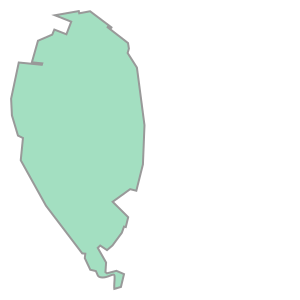

In [2]:
# This cell loads and plots the wetlands polygon. If no output, check your polygon
poly = gpd.read_file("../Supplementary_data/DEA_Wetlands_Insight_Tool/hird.shp")
poly.geometry[0]

### Run the WIT polygon drill function?

In [3]:
 ds_wit, polygon_base_df = dea_tools.wetlands.WIT_drill(
                        gdf=poly,
                        time=("2018-01-01", "2020-01-01"),
                        #export_csv="results.csv"
                        )

Finding datasets
    ga_ls8c_ard_3
    ga_ls7e_ard_3 (ignoring SLC-off observations)
    ga_ls5t_ard_3
Applying fmask pixel quality/cloud mask
Returning 90 time steps as a dask array


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2']


## Create WIT Comma-separated values (CSV) output file
The output file will show up in the file explorer in this directory. 


In [4]:
polygon_name = "Hird Swamp"

In [5]:
output_df = polygon_base_df.drop(columns=["index"]).set_index("date")
output_df.head()

,pv,npv,bs,wet,water,veg_areas,overall_veg_num,norm_bs,norm_pv,norm_npv
date,,,,,,,,,,
2018-01-07 00:15:31.934073,0.367181,0.293586,0.085827,0.091682,0.148932,0.759386,0.746594,0.087297,0.373472,0.298617
2018-01-16 00:09:16.940377,0.376978,0.299208,0.088942,0.080481,0.141257,0.778262,0.765128,0.090469,0.383449,0.304344
2018-01-23 00:15:23.780873,0.396855,0.332336,0.067175,0.073221,0.117403,0.809376,0.796366,0.068272,0.403339,0.337765
2018-02-01 00:09:07.083433,0.391363,0.342387,0.097370,0.056420,0.098942,0.844638,0.831120,0.098954,0.397728,0.347956
2018-02-08 00:15:15.801616,0.402016,0.373692,0.091636,0.047782,0.070819,0.881399,0.867344,0.093121,0.408530,0.379748


In [6]:
output_df.to_csv(f"{polygon_name}.csv", index=True)

In [7]:
agg_data = output_df.groupby(output_df.index.year).agg(pv_sum=('pv', 'sum'))
agg_data

,pv_sum
date,
2018,12.393691
2019,8.035043


In [8]:
wit_df = output_df.loc[:, ["pv",
    "npv",
    "bs",
    "wet",
    "water",]]

In [9]:
members=[
    "pv",
    "npv",
    "bs",
    "wet",
    "water",
    ["npv", "pv", "wet"],
    ["pv", "wet"],
    ["water", "wet"],
]

In [10]:
for m in members:
    if isinstance(m, list):
        wit_df.insert(wit_df.columns.size, "+".join(m), wit_df[m].sum(axis=1))

In [52]:
wit_max = wit_df.resample("YS").max(numeric_only=True)
wit_max = wit_max.rename(columns={n: n + "_max" for n in wit_max.columns})

wit_min = wit_df.resample("YS").min(numeric_only=True)
wit_min = wit_min.rename(columns={n: n + "_min" for n in wit_min.columns})

wit_mean = wit_df.resample("YS").mean(numeric_only=True)
wit_mean = wit_mean.rename(columns={n: n + "_mean" for n in wit_mean.columns})

wit_median = wit_df.resample("YS").median(numeric_only=True)
wit_median = wit_median.rename(
    columns={n: n + "_median" for n in wit_median.columns}
)
wit_count = (
    output_df["bs"]
    .resample("YS")
    .count()
    .rename("count")
)

In [53]:
wit_yearly_metrics = pd.concat(
    [wit_max, wit_min, wit_mean, wit_median, wit_count], axis=1
).reset_index(level="date")
wit_yearly_metrics.insert(1, "year", wit_yearly_metrics["date"].dt.year)

In [14]:
wit_yearly_metrics

,date,year,pv_max,npv_max,bs_max,wet_max,water_max,npv+pv+wet_max,pv+wet_max,water+wet_max,...,water+wet_mean,pv_median,npv_median,bs_median,wet_median,water_median,npv+pv+wet_median,pv+wet_median,water+wet_median,count
0,2018-01-01,2018,0.439882,0.480718,0.151954,0.217791,0.148932,0.898612,0.584578,0.255697,...,0.109371,0.401632,0.373692,0.100311,0.073221,0.001452,0.870481,0.458863,0.118601,31
1,2019-01-01,2019,0.442230,0.655184,0.156420,0.000000,0.000000,0.876575,0.442230,0.000000,...,0.000000,0.338974,0.517168,0.131320,0.000000,0.000000,0.854237,0.338974,0.000000,24


## Calculating summary statistics

The WIT results can be analysed to determine the minimum, median and maximum values for the wetland polygon of interest. Summary statistics for each year or per season can be calculate. These are exported as `csv` files.

Please note that if the time period selected cuts through a season or year these summary statistics may be incomplete. 

In [15]:
output_df.index = pd.to_datetime(output_df.index)

In [17]:
WIT_max = output_df["pv"].resample("YS").max(numeric_only = True)

In [18]:
WIT_max

date
2018-01-01    0.439882
2019-01-01    0.442230
Freq: YS-JAN, Name: pv, dtype: float64

In [60]:
def yearly_stats(output_df, polygon_name):
    # Convert the index of the DataFrame to datetime format
    output_df.index = pd.to_datetime(output_df.index)

    # Extract the year from the index and create a new column 'year'
    output_df['year'] = output_df.index.year

    yearly_stats = pd.DataFrame()
       
    # Calculate yearly statistics 
    stats_df_yearly = output_df.groupby('year').agg({
        "pv": ["min", "median", "max"],
        "npv": ["min", "median", "max"],
        "bs": ["min", "median", "max"],
        "wet": ["min", "median", "max"],
        "water": ["min", "median", "max"]
    })
            
    # Fix column names after aggregation
    stats_df_yearly.columns = ['_'.join(col) for col in stats_df_yearly.columns]

    # Append the yearly statistics to the yearly_stats DataFrame
    yearly_stats = pd.concat([yearly_stats, stats_df_yearly])

    # Write stats dataframe to csv 
    yearly_stats.to_csv(f"{polygon_name}_stats.csv", index=True)
    
    return yearly_stats

In [61]:
def seasonal_stats(output_df, polygon_name):
    # Convert the index of the DataFrame to datetime format
    output_df.index = pd.to_datetime(output_df.index)

    # Extract the year from the index and create a new column 'year'
    output_df['year'] = output_df.index.year

    # Define seasons and their corresponding months
    seasons = {
        'summer': [12, 1, 2],
        'autumn': [3, 4, 5],
        'winter': [6, 7, 8],
        'spring': [9, 10, 11]
    }

    all_seasons_stats = pd.DataFrame()
    
    #Calculate seasonal statistics 
    for season, months in seasons.items():
        # Filter the DataFrame to include only the months for the current season
        season_df = output_df[output_df.index.month.isin(months)]

        # Adjust the year for December to be considered as part of the next year's summer
        if season == 'summer':
            season_df.loc[season_df.index.month == 12, 'year'] += 1

        # Create a new column for year-season combination
        season_df['year_season'] = season_df['year'].astype(str) + '-' + season

        # Group the DataFrame by the 'year_season' column and calculate the minimum, median, and maximum values
        stats_df_seasonal = season_df.groupby('year_season').agg({
            "pv": ["min", "median", "max"],
            "npv": ["min", "median", "max"],
            "bs": ["min", "median", "max"],
            "wet": ["min", "median", "max"],
            "water": ["min", "median", "max"]
        })

        # Fix column names after aggregation
        stats_df_seasonal.columns = ['_'.join(col) for col in stats_df_seasonal.columns]

        # Append the seasonal statistics to the all_seasons_stats DataFrame
        all_seasons_stats = pd.concat([all_seasons_stats, stats_df_seasonal])

        # Define custom season order
        season_order = {'summer': 0, 'autumn': 1, 'winter': 2, 'spring': 3}

        # Reorder output to group year and then season chronologically 
        all_seasons_stats['year'] = all_seasons_stats.index.str.split('-').str[0]
        all_seasons_stats['season'] = all_seasons_stats.index.str.split('-').str[1]
        all_seasons_stats["season_order"] = all_seasons_stats["season"].map(season_order)
        all_seasons_stats = all_seasons_stats.sort_values(by=['year', 'season_order'])
        all_seasons_stats = all_seasons_stats.drop(columns=['year', 'season', 'season_order'])

        # Save to a CSV file
        all_seasons_stats.to_csv(f"{polygon_name}_seasonal_stats.csv", index=True)

        
    return all_seasons_stats

In [62]:
# Yearly summary statistics
yearly_stats = yearly_stats(output_df, polygon_name)

In [63]:
# Seasonal summary statistics
seasonal_stats = seasonal_stats(output_df, polygon_name)

The results can be viewed as a table, with values coloured from highest to lowest for each column. 

In [64]:
yearly_stats_styled = yearly_stats.style.background_gradient(axis=0, cmap='BuGn')
seasonal_stats_styled = seasonal_stats.style.background_gradient(axis=0, cmap='BuGn')

In [65]:
# Summary table of the yearly statistics 
yearly_stats_styled

,pv_min,pv_median,pv_max,npv_min,npv_median,npv_max,bs_min,bs_median,bs_max,wet_min,wet_median,wet_max,water_min,water_median,water_max
year,,,,,,,,,,,,,,,
2018,0.357455,0.401632,0.439882,0.287489,0.373692,0.480718,0.067175,0.100311,0.151954,0.000000,0.073221,0.217791,0.000000,0.001452,0.148932
2019,0.181228,0.338974,0.442230,0.419235,0.517168,0.655184,0.109826,0.131320,0.156420,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [66]:
# Summary table of the seasonal statistics 
seasonal_stats_styled

,pv_min,pv_median,pv_max,npv_min,npv_median,npv_max,bs_min,bs_median,bs_max,wet_min,wet_median,wet_max,water_min,water_median,water_max
year_season,,,,,,,,,,,,,,,
2018-summer,0.367181,0.394109,0.436907,0.293586,0.337362,0.404474,0.067175,0.090289,0.107335,0.013068,0.064821,0.091682,0.023024,0.108173,0.148932
2018-autumn,0.357455,0.384690,0.415534,0.287489,0.310902,0.365040,0.081163,0.095123,0.109019,0.082348,0.153080,0.217791,0.000000,0.007467,0.114914
2018-winter,0.370249,0.399091,0.439882,0.375362,0.403999,0.436326,0.097913,0.100527,0.118857,0.011823,0.057872,0.124870,0.000830,0.002074,0.002697
2018-spring,0.401632,0.415802,0.433750,0.441193,0.450672,0.480718,0.096992,0.106027,0.141688,0.000000,0.000000,0.006223,0.000000,0.000000,0.001246
2019-summer,0.326436,0.357389,0.417689,0.418739,0.512132,0.544095,0.109826,0.130526,0.151954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-autumn,0.323070,0.329391,0.350193,0.495559,0.520743,0.535984,0.127048,0.134616,0.139627,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-winter,0.347517,0.399062,0.442230,0.419235,0.460549,0.515733,0.114354,0.129798,0.143111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2019-spring,0.199098,0.274976,0.320838,0.541850,0.596387,0.631987,0.116476,0.124024,0.156420,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-summer,0.181228,0.185840,0.190452,0.652375,0.653779,0.655184,0.145053,0.148396,0.151738,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Plotting statistics

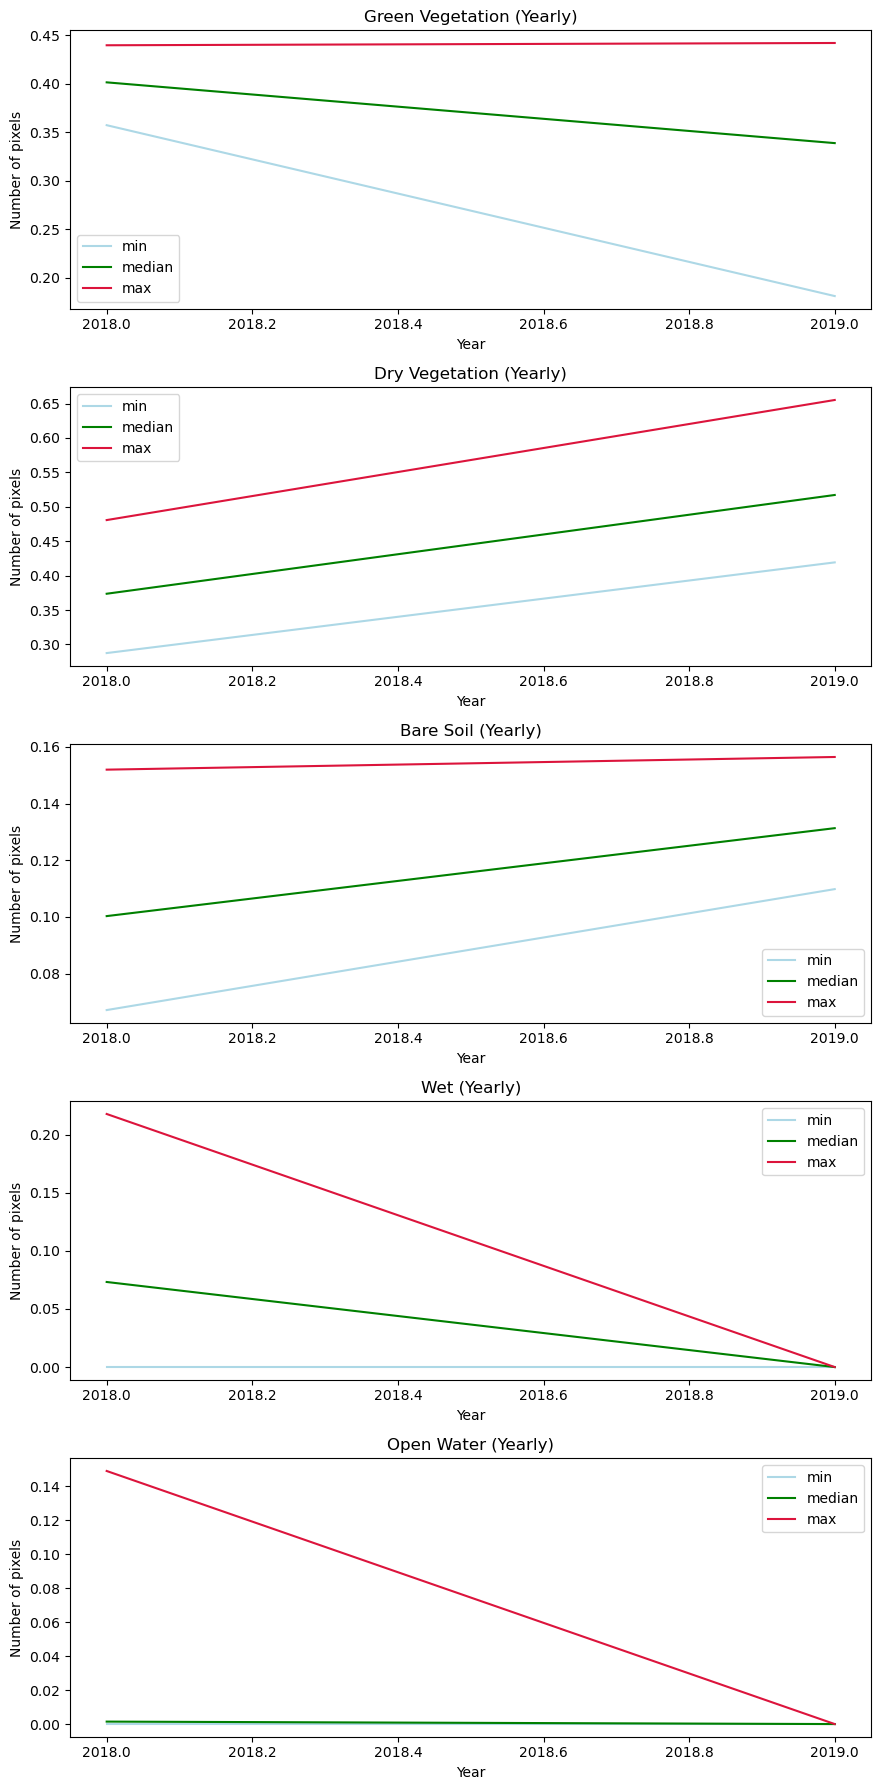

In [26]:
fig, axs = plt.subplots(5,1, figsize=(9,18))

# Plotting pv values
axs[0].plot(yearly_stats.index, yearly_stats['pv_min'], label='min', color='lightblue')
axs[0].plot(yearly_stats.index, yearly_stats['pv_median'], label='median', color='green')
axs[0].plot(yearly_stats.index, yearly_stats['pv_max'], label='max', color='crimson')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Number of pixels')
axs[0].set_title('Green Vegetation (Yearly)')
axs[0].legend()

# Plotting npv values
axs[1].plot(yearly_stats.index, yearly_stats['npv_min'], label='min', color='lightblue')
axs[1].plot(yearly_stats.index, yearly_stats['npv_median'], label='median', color='green')
axs[1].plot(yearly_stats.index, yearly_stats['npv_max'], label='max', color='crimson')
axs[1].set_xlabel('Year')
axs[1].set_ylabel('Number of pixels')
axs[1].set_title('Dry Vegetation (Yearly)')
axs[1].legend()

# Plotting bs values
axs[2].plot(yearly_stats.index, yearly_stats['bs_min'], label='min', color='lightblue')
axs[2].plot(yearly_stats.index, yearly_stats['bs_median'], label='median', color='green')
axs[2].plot(yearly_stats.index, yearly_stats['bs_max'], label='max', color='crimson')
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Number of pixels')
axs[2].set_title('Bare Soil (Yearly)')
axs[2].legend()

# Plotting wet values
axs[3].plot(yearly_stats.index, yearly_stats['wet_min'], label='min', color='lightblue')
axs[3].plot(yearly_stats.index, yearly_stats['wet_median'], label='median', color='green')
axs[3].plot(yearly_stats.index, yearly_stats['wet_max'], label='max', color='crimson')
axs[3].set_xlabel('Year')
axs[3].set_ylabel('Number of pixels')
axs[3].set_title('Wet (Yearly)')
axs[3].legend()

# Plotting water values
axs[4].plot(yearly_stats.index, yearly_stats['water_min'], label='min', color='lightblue')
axs[4].plot(yearly_stats.index, yearly_stats['water_median'], label='median', color='green')
axs[4].plot(yearly_stats.index, yearly_stats['water_max'], label='max', color='crimson')
axs[4].set_xlabel('Year')
axs[4].set_ylabel('Number of pixels')
axs[4].set_title('Open Water (Yearly)')
axs[4].legend()

plt.tight_layout()
plt.show()

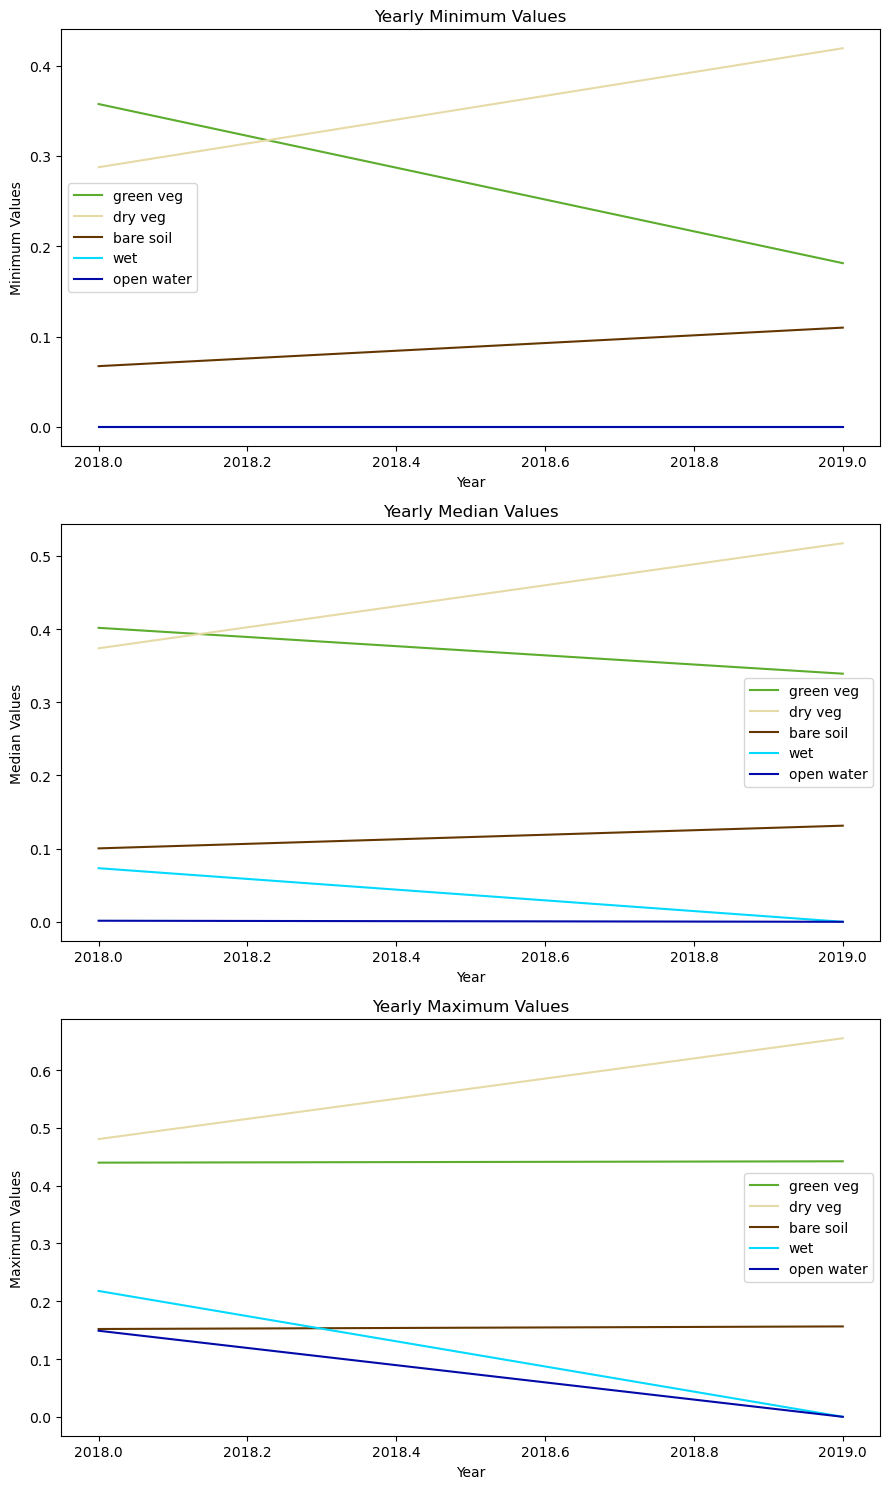

In [27]:
fig, axs = plt.subplots(3,1, figsize=(9,15))

# Plotting min values
axs[0].plot(yearly_stats.index, yearly_stats['pv_min'], label='green veg', color=sns.xkcd_rgb['grass'])
axs[0].plot(yearly_stats.index, yearly_stats['npv_min'], label='dry veg', color=sns.xkcd_rgb['beige'])
axs[0].plot(yearly_stats.index, yearly_stats['bs_min'], label='bare soil', color=sns.xkcd_rgb['brown'])
axs[0].plot(yearly_stats.index, yearly_stats['wet_min'], label='wet', color=sns.xkcd_rgb['neon blue'])
axs[0].plot(yearly_stats.index, yearly_stats['water_min'], label='open water', color=sns.xkcd_rgb['cobalt blue'])
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Minimum Values')
axs[0].set_title('Yearly Minimum Values')
axs[0].legend()

# Plotting median values
axs[1].plot(yearly_stats.index, yearly_stats['pv_median'], label='green veg', color=sns.xkcd_rgb['grass'])
axs[1].plot(yearly_stats.index, yearly_stats['npv_median'], label='dry veg', color=sns.xkcd_rgb['beige'])
axs[1].plot(yearly_stats.index, yearly_stats['bs_median'], label='bare soil', color=sns.xkcd_rgb['brown'])
axs[1].plot(yearly_stats.index, yearly_stats['wet_median'], label='wet', color=sns.xkcd_rgb['neon blue'])
axs[1].plot(yearly_stats.index, yearly_stats['water_median'], label='open water', color=sns.xkcd_rgb['cobalt blue'])
axs[1].set_xlabel('Year')
axs[1].set_ylabel('Median Values')
axs[1].set_title('Yearly Median Values')
axs[1].legend()

# Plotting max values
axs[2].plot(yearly_stats.index, yearly_stats['pv_max'], label='green veg', color=sns.xkcd_rgb['grass'])
axs[2].plot(yearly_stats.index, yearly_stats['npv_max'], label='dry veg', color=sns.xkcd_rgb['beige'])
axs[2].plot(yearly_stats.index, yearly_stats['bs_max'], label='bare soil', color=sns.xkcd_rgb['brown'])
axs[2].plot(yearly_stats.index, yearly_stats['wet_max'], label='wet', color=sns.xkcd_rgb['neon blue'])
axs[2].plot(yearly_stats.index, yearly_stats['water_max'], label='open water', color=sns.xkcd_rgb['cobalt blue'])
axs[2].set_xlabel('Year')
axs[2].set_ylabel('Maximum Values')
axs[2].set_title('Yearly Maximum Values')
axs[2].legend()

plt.tight_layout()
plt.show()

[]

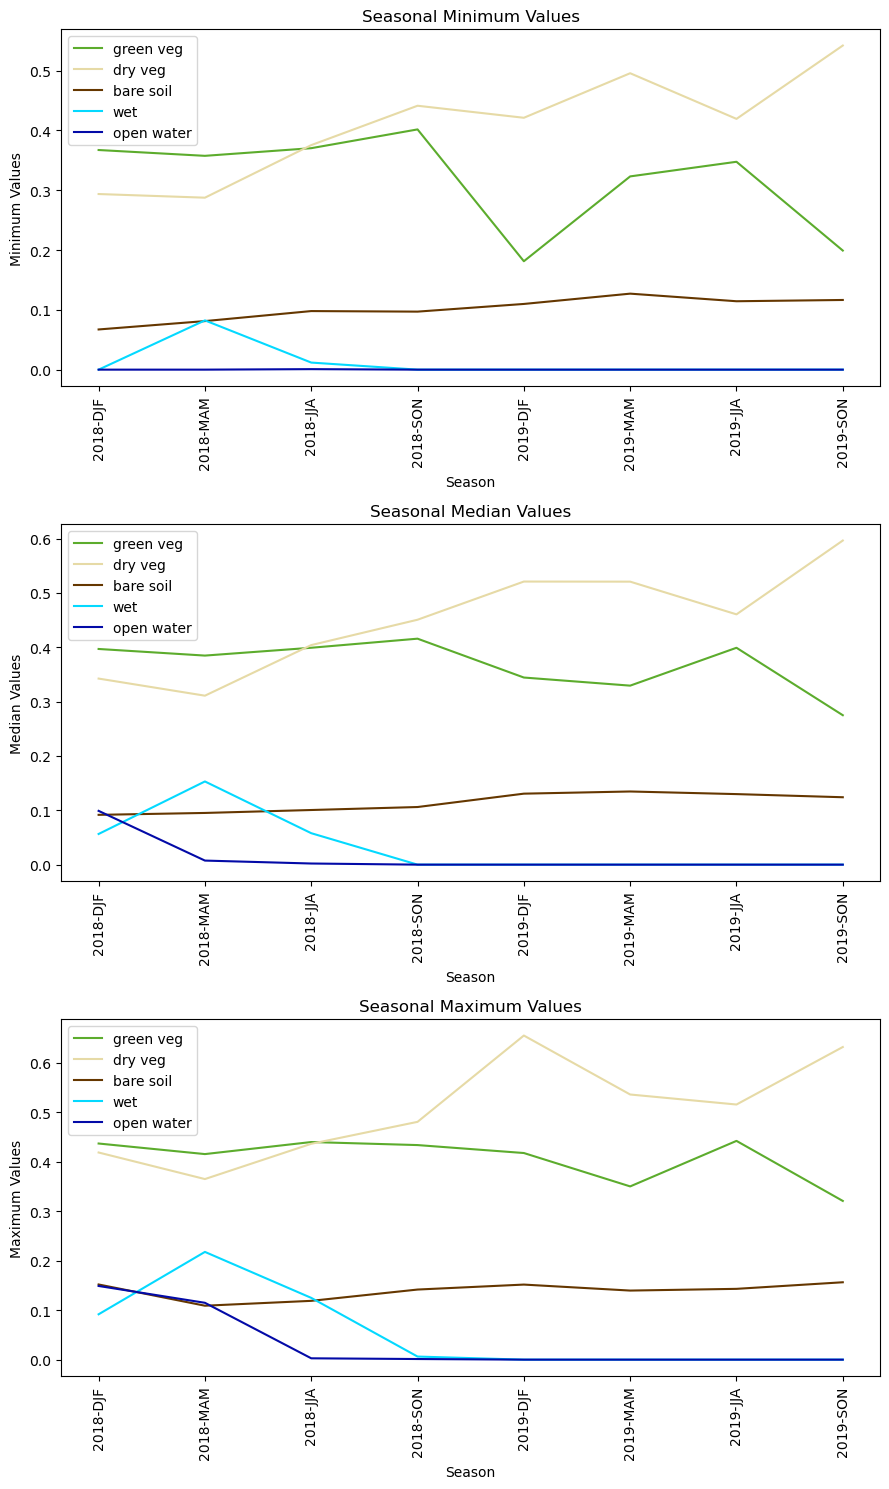

In [28]:
fig, axs = plt.subplots(3,1, figsize=(9,15))

# Plotting min values
axs[0].plot(seasonal_stats.index, seasonal_stats['pv_min'], label='green veg', color=sns.xkcd_rgb['grass'])
axs[0].plot(seasonal_stats.index, seasonal_stats['npv_min'], label='dry veg', color=sns.xkcd_rgb['beige'])
axs[0].plot(seasonal_stats.index, seasonal_stats['bs_min'], label='bare soil', color=sns.xkcd_rgb['brown'])
axs[0].plot(seasonal_stats.index, seasonal_stats['wet_min'], label='wet', color=sns.xkcd_rgb['neon blue'])
axs[0].plot(seasonal_stats.index, seasonal_stats['water_min'], label='open water', color=sns.xkcd_rgb['cobalt blue'])
axs[0].set_xlabel('Season')
axs[0].tick_params(axis='x', labelrotation=90)
axs[0].set_ylabel('Minimum Values')
axs[0].set_title('Seasonal Minimum Values')
axs[0].legend()

# Plotting median values
axs[1].plot(seasonal_stats.index, seasonal_stats['pv_median'], label='green veg', color=sns.xkcd_rgb['grass'])
axs[1].plot(seasonal_stats.index, seasonal_stats['npv_median'], label='dry veg', color=sns.xkcd_rgb['beige'])
axs[1].plot(seasonal_stats.index, seasonal_stats['bs_median'], label='bare soil', color=sns.xkcd_rgb['brown'])
axs[1].plot(seasonal_stats.index, seasonal_stats['wet_median'], label='wet', color=sns.xkcd_rgb['neon blue'])
axs[1].plot(seasonal_stats.index, seasonal_stats['water_median'], label='open water', color=sns.xkcd_rgb['cobalt blue'])
axs[1].set_xlabel('Season')
axs[1].tick_params(axis='x', labelrotation=90)
axs[1].set_ylabel('Median Values')
axs[1].set_title('Seasonal Median Values')
axs[1].legend()

# Plotting max values
axs[2].plot(seasonal_stats.index, seasonal_stats['pv_max'], label='green veg', color=sns.xkcd_rgb['grass'])
axs[2].plot(seasonal_stats.index, seasonal_stats['npv_max'], label='dry veg', color=sns.xkcd_rgb['beige'])
axs[2].plot(seasonal_stats.index, seasonal_stats['bs_max'], label='bare soil', color=sns.xkcd_rgb['brown'])
axs[2].plot(seasonal_stats.index, seasonal_stats['wet_max'], label='wet', color=sns.xkcd_rgb['neon blue'])
axs[2].plot(seasonal_stats.index, seasonal_stats['water_max'], label='open water', color=sns.xkcd_rgb['cobalt blue'])
axs[2].set_xlabel('Season')
axs[2].tick_params(axis='x', labelrotation=90)
axs[2].set_ylabel('Maximum Values')
axs[2].set_title('Seasonal Maximum Values')
axs[2].legend()

plt.tight_layout()
plt.plot()

In [29]:
std_dev = output_df.std
std_dev

<bound method DataFrame.std of                                   pv       npv        bs       wet     water  \
date                                                                           
2018-01-07 00:15:31.934073  0.367181  0.293586  0.085827  0.091682  0.148932   
2018-01-16 00:09:16.940377  0.376978  0.299208  0.088942  0.080481  0.141257   
2018-01-23 00:15:23.780873  0.396855  0.332336  0.067175  0.073221  0.117403   
2018-02-01 00:09:07.083433  0.391363  0.342387  0.097370  0.056420  0.098942   
2018-02-08 00:15:15.801616  0.402016  0.373692  0.091636  0.047782  0.070819   
2018-02-17 00:09:01.976812  0.436907  0.404474  0.107335  0.013068  0.023024   
2018-03-05 00:08:54.336459  0.380112  0.309233  0.104287  0.082348  0.110765   
2018-03-12 00:15:00.935920  0.357455  0.301021  0.101344  0.112632  0.114914   
2018-03-21 00:08:45.937021  0.370979  0.322939  0.086107  0.104128  0.103091   
2018-04-06 00:08:38.542500  0.379166  0.308714  0.085279  0.187720  0.026136   
2018-04-1

In [30]:
#yearly_stats.index = pd.to_datetime(yearly_stats.index, format='%Y')

<Axes: xlabel='year'>

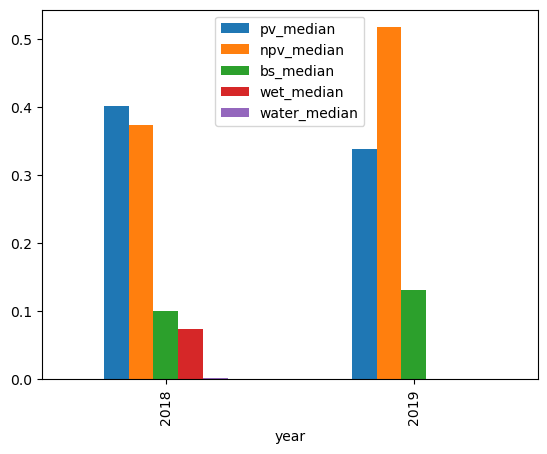

In [31]:
yearly_stats[["pv_median", "npv_median", "bs_median", "wet_median", "water_median"]].plot(kind="bar")

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
x = np.arange(len(yearly_stats.index))
#width=0.25

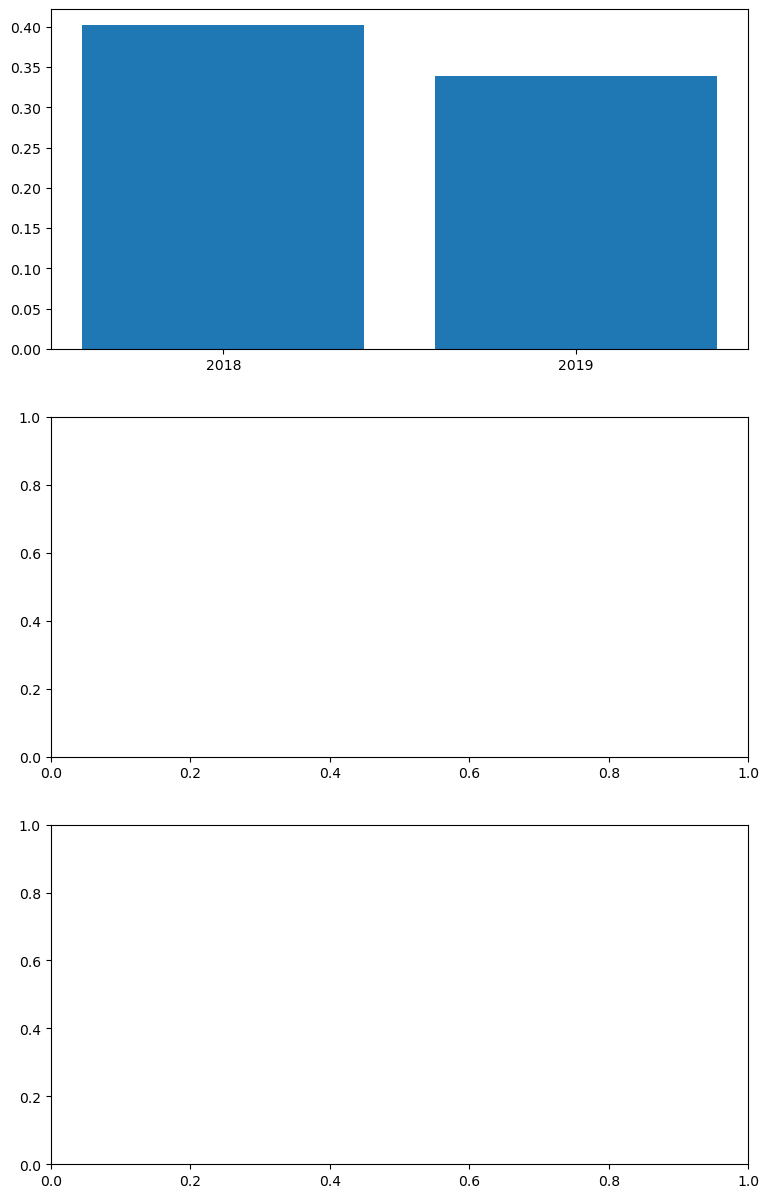

In [34]:
fig, ax = plt.subplots(3,1, figsize=(9,15))

ax[0].bar(x, yearly_stats["pv_median"])
ax[0].set_xticks(x, yearly_stats.index)

<Axes: xlabel='year_season'>

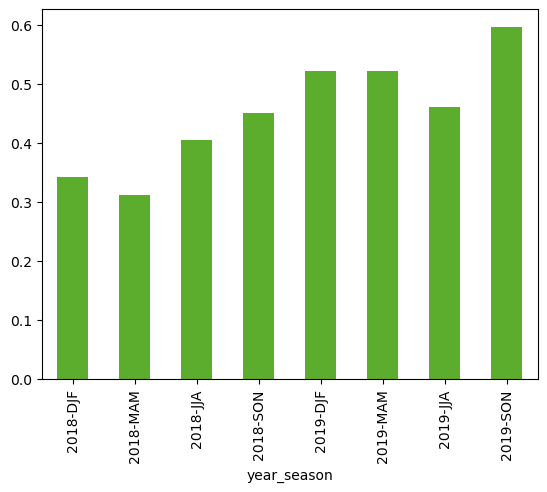

In [35]:
seasonal_stats["npv_median"].plot(kind="bar", color=sns.xkcd_rgb['grass'])

In [36]:
output_df.index = pd.to_datetime(output_df.index)

# Extract the year from the index and create a new column 'year'
output_df['year'] = output_df.index.year

# Calculate yearly statistics 
stats_df_yearly = output_df.groupby('year').agg({
    "pv": ["min", "median", "max"],
    "npv": ["min", "median", "max"],
    "bs": ["min", "median", "max"],
    "wet": ["min", "median", "max"],
    "water": ["min", "median", "max"]
})
            
# Fix column names after aggregation
stats_df_yearly.columns = ['_'.join(col) for col in stats_df_yearly.columns]

In [37]:
stats_df_yearly.head()

,pv_min,pv_median,pv_max,npv_min,npv_median,npv_max,bs_min,bs_median,bs_max,wet_min,wet_median,wet_max,water_min,water_median,water_max
year,,,,,,,,,,,,,,,
2018,0.357455,0.401632,0.439882,0.287489,0.373692,0.480718,0.067175,0.100311,0.151954,0.0,0.073221,0.217791,0.0,0.001452,0.148932
2019,0.181228,0.338974,0.442230,0.419235,0.517168,0.655184,0.109826,0.131320,0.156420,0.0,0.000000,0.000000,0.0,0.000000,0.000000


In [38]:
medians_df = stats_df_yearly.filter(like='median')

In [39]:
df_yearly = output_df.groupby('year').describe()
df_yearly.columns = ['_'.join(col) for col in df_yearly.columns]

In [40]:
df_yearly.head()

,pv_count,pv_mean,pv_std,pv_min,pv_25%,pv_50%,pv_75%,pv_max,npv_count,npv_mean,...,norm_pv_75%,norm_pv_max,norm_npv_count,norm_npv_mean,norm_npv_std,norm_npv_min,norm_npv_25%,norm_npv_50%,norm_npv_75%,norm_npv_max
year,,,,,,,,,,,,,,,,,,,,,
2018,31.0,0.399796,0.023114,0.357455,0.382401,0.401632,0.414537,0.439882,31.0,0.374998,...,0.421333,0.446844,31.0,0.380956,0.062465,0.292462,0.319337,0.379748,0.445444,0.487357
2019,24.0,0.334793,0.068186,0.181228,0.324556,0.338974,0.365749,0.442230,24.0,0.520443,...,0.370906,0.448793,24.0,0.527731,0.064506,0.425729,0.493261,0.524743,0.544940,0.663041


In [41]:
output_df

,pv,npv,bs,wet,water,veg_areas,overall_veg_num,norm_bs,norm_pv,norm_npv,year
date,,,,,,,,,,,
2018-01-07 00:15:31.934073,0.367181,0.293586,0.085827,0.091682,0.148932,0.759386,0.746594,0.087297,0.373472,0.298617,2018
2018-01-16 00:09:16.940377,0.376978,0.299208,0.088942,0.080481,0.141257,0.778262,0.765128,0.090469,0.383449,0.304344,2018
2018-01-23 00:15:23.780873,0.396855,0.332336,0.067175,0.073221,0.117403,0.809376,0.796366,0.068272,0.403339,0.337765,2018
2018-02-01 00:09:07.083433,0.391363,0.342387,0.097370,0.056420,0.098942,0.844638,0.831120,0.098954,0.397728,0.347956,2018
2018-02-08 00:15:15.801616,0.402016,0.373692,0.091636,0.047782,0.070819,0.881399,0.867344,0.093121,0.408530,0.379748,2018
2018-02-17 00:09:01.976812,0.436907,0.404474,0.107335,0.013068,0.023024,0.963908,0.948716,0.109053,0.443904,0.410951,2018
2018-03-05 00:08:54.336459,0.380112,0.309233,0.104287,0.082348,0.110765,0.806887,0.793632,0.106029,0.386460,0.314397,2018
2018-03-12 00:15:00.935920,0.357455,0.301021,0.101344,0.112632,0.114914,0.772454,0.759820,0.103029,0.363399,0.306026,2018
2018-03-21 00:08:45.937021,0.370979,0.322939,0.086107,0.104128,0.103091,0.792782,0.780025,0.087515,0.377046,0.328221,2018


In [42]:
# all time mean
threshold = output_df['npv'].mean()

In [43]:
min_year = df_yearly.index.min()
max_year = df_yearly.index.max()
max_lim = max_year + 1

In [44]:
df_yearly["pv_75%"]

year
2018    0.414537
2019    0.365749
Name: pv_75%, dtype: float64

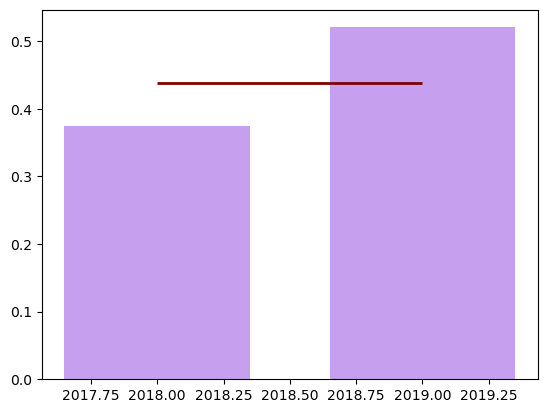

In [45]:
width = 0.7
fig, ax = plt.subplots()
ax.bar(df_yearly.index, df_yearly["npv_mean"], width=width, color='#C79FEF')
ax.hlines(y=[threshold], xmin=min_year, xmax=max_year, linewidth=2, color='maroon')

In [46]:
import seaborn as sns
import datetime
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

In [47]:
medians_df = medians_df.reset_index()

In [48]:
medians_df = medians_df.rename(columns={"pv_median":"pv", "npv_median":"npv", "bs_median":"bs", "wet_median":"wet", "water_median":"water", "year":"date"})
medians_df.head()

,date,pv,npv,bs,wet,water
0,2018,0.401632,0.373692,0.100311,0.073221,0.001452
1,2019,0.338974,0.517168,0.131320,0.000000,0.000000


In [49]:
medians_df['date'] = pd.to_datetime(medians_df['date'], format='%Y')
medians_df

,date,pv,npv,bs,wet,water
0,2018-01-01,0.401632,0.373692,0.100311,0.073221,0.001452
1,2019-01-01,0.338974,0.517168,0.131320,0.000000,0.000000


In [50]:
def display_wit_stack_with_df(
    polygon_base_df,
    polygon_name="your_wetland_name",
    png_name="your_file_name",
    width=32,
    height=6,
    x_axis_labels="years"
):
    """
    This functions produces WIT plots. Function displays a stack plot and saves as a png.

    Last modified: July 2023

    Parameters
    ----------
    polygon_base_df : pandas DataFrame with columns including:
    ['date',
     'wet',
     'water',
     'norm_bs',
     'norm_pv',
     'norm_npv']
     polygon_name : string
     png_name : string
     x_axis_labels : string with options of "years" or "months" 
     to set either years or months on the x axis as labels
     

    """

    plt.rcParams["axes.facecolor"] = "white"
    plt.rcParams["savefig.facecolor"] = "white"
    plt.rcParams["text.usetex"] = False

    fig = plt.figure()
    fig.set_size_inches(width, height)
    ax = fig.add_subplot(111)
    ax.autoscale(enable=True)

    pal = [
        sns.xkcd_rgb["cobalt blue"],
        sns.xkcd_rgb["neon blue"],
        sns.xkcd_rgb["grass"],
        sns.xkcd_rgb["beige"],
        sns.xkcd_rgb["brown"],
    ]

    plt.title(
        f"Percentage of area dominated by WOfS, Wetness, Fractional Cover for\n {polygon_name}",
        fontsize=16,
    )

    ax.stackplot(
        polygon_base_df["date"],
        polygon_base_df["water"],
        polygon_base_df["wet"],
        polygon_base_df["pv"],
        polygon_base_df["npv"],
        polygon_base_df["bs"],
        colors=pal,
        alpha=0.7,
    )

    # manually change the legend display order
    legend = ax.legend(
        ["open water", "wet", "green veg", "dry veg", "bare soil"][::-1],
        loc="lower left",
    )
    handles = legend.legend_handles

    for i, handle in enumerate(handles):
        handle.set_facecolor(pal[::-1][i])
        handle.set_alpha(0.7)

    # setup the display ranges
    #ax.set_ylim(0, 100)
    ax.set_xlim(polygon_base_df["date"].min(), polygon_base_df["date"].max())

    if x_axis_labels=="years":
        # modify the xaxis settings
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        
    if x_axis_labels=="months":
       # modify the xaxis settings
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
        # Rotates and right-aligns the x labels so they don't crowd each other.
        for label in ax.get_xticklabels(which='major'):
            label.set(rotation=30, horizontalalignment='right')
        
    x_label_text = "The Fractional Cover algorithm developed by the Joint Remote Sensing Research Program and\n the Water Observations from Space algorithm developed by Geoscience Australia are used in the production of this data"

    ax.set_xlabel(x_label_text, style="italic")

    plt.savefig(f"{png_name}.png", bbox_inches="tight")
    plt.show()

    plt.close(fig)

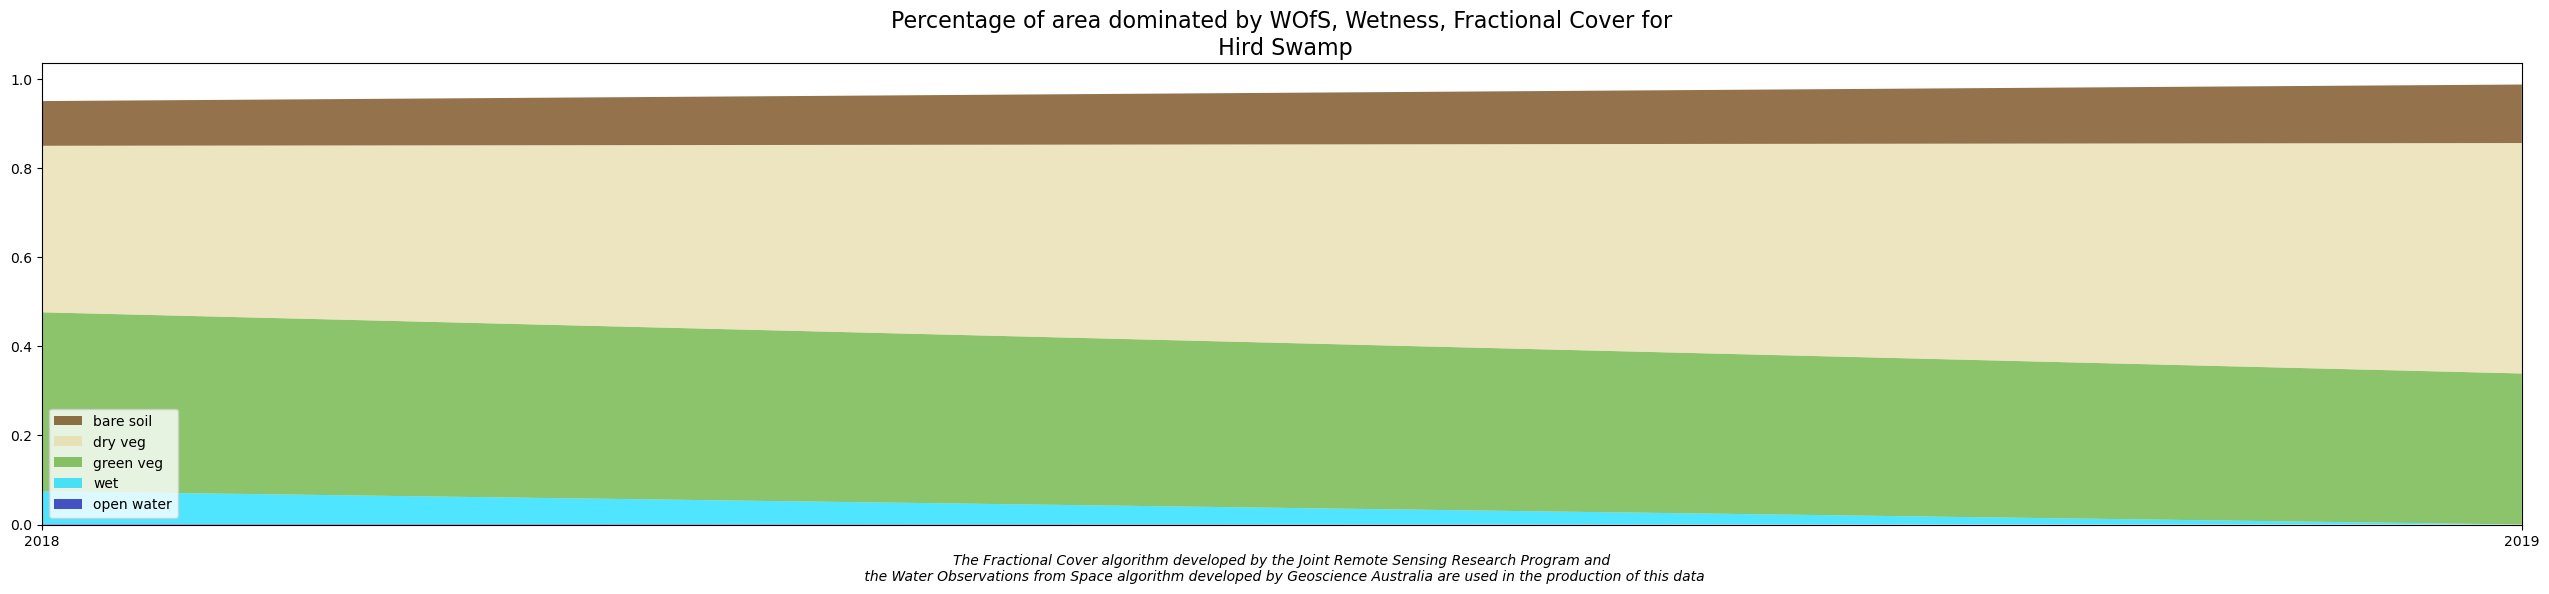

In [51]:
display_wit_stack_with_df(medians_df, polygon_name, polygon_name, x_axis_labels="years")